In [1]:
import sys
print(sys.prefix)

/home/rafihaqul/project/Airport_X-Ray_Guard_System/.venv3-12


In [2]:
pip install matplotlib seaborn pandas kagglehub==0.3.13

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import json
import kagglehub
import os
import shutil
import math
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

/home/rafihaqul/project/Airport_X-Ray_Guard_System/.venv3-12/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Load

In [4]:
# Download latest version
path = kagglehub.dataset_download("yuzheguocs/ldxray")

print("Path to dataset files:", path)

Path to dataset files: /home/rafihaqul/.cache/kagglehub/datasets/yuzheguocs/ldxray/versions/3


In [5]:
# Raw data
raw_images_train = path + "/dataset/train_A" 
raw_images_test  = path + "/dataset/test_A"
raw_labels_train = path + "/train.json"
raw_labels_test  = path + "/test.json"

# Temporary data / data sementara / data singah
# temp_images_train= "../data/temp/images/train"
temp_images_test = "../data/temp/images/test"
# temp_labels_train= "../data/temp/labels/train"
temp_labels_test = "../data/temp/labels/test"

# Data Processed / data yang sudah di proses dan siap pakai
processed_images_train = "../data/processed/images/train"
processed_images_val   = "../data/processed/images/val"
processed_images_test  = "../data/processed/images/test"
processed_labels_train = "../data/processed/labels/train"
processed_labels_val   = "../data/processed/labels/val"
processed_labels_test  = "../data/processed/labels/test"

In [6]:
# Read the test data
with open(raw_labels_test, 'r') as f:
    data_test = json.load(f)

images_test = data_test['images']
annotations_test = data_test['annotations']

# Read the training data
with open(raw_labels_train, 'r') as f:
    data_train = json.load(f)

images_train = data_train['images']
annotations_train = data_train['annotations']


# Create YOLO labels

In [7]:
# Fungsi untuk membangun mapping dari image_id ke nama file 
# (tanpa ekstensi) dan ke dimensi gambar
def build_image_maps(images):
    id_to_filename_and_size = {
        img["id"]: (os.path.splitext(img["file_name"])[0], (img["width"], img["height"]))
        for img in images
    }
    return id_to_filename_and_size

# Fungsi untuk mencetak contoh mapping dan dimensi gambar
def print_samples(title, items, formatter, n=3):
    print(title)
    for item in list(items)[:n]:
        print(formatter(item))

test_id_to_filename_and_size = build_image_maps(images_test)
train_id_to_filename_and_size = build_image_maps(images_train)

print_samples(
    "Contoh sampel test:",
    test_id_to_filename_and_size.items(),
    lambda kv: f"  id={kv[0]}  →  {kv[1][0]}.txt, size={kv[1][1]}"
)

print_samples(
    "Contoh sampel training:",
    train_id_to_filename_and_size.items(),
    lambda kv: f"  id={kv[0]}  →  {kv[1][0]}.txt, size={kv[1][1]}"
)

Contoh sampel test:
  id=1  →  000000.txt, size=(440, 1040)
  id=2  →  000001.txt, size=(436, 1040)
  id=3  →  000002.txt, size=(504, 1040)
Contoh sampel training:
  id=1  →  000000.txt, size=(548, 1040)
  id=2  →  000001.txt, size=(472, 1040)
  id=3  →  000002.txt, size=(492, 1040)


In [8]:
def check_ann_per_image(annotations):
    ann_per_image = defaultdict(list)
    
    for ann in annotations:
        img_id      = ann["image_id"]
        category_id = ann["category_id"]
        bbox        = ann["bbox"]      # [x_min, y_min, width, height] COCO
        ann_per_image[img_id].append({
            "category_id": category_id,
            "bbox": bbox
        })
    
    return ann_per_image

# Gunakan untuk test dan train
ann_per_image_test = check_ann_per_image(annotations_test)
ann_per_image_train = check_ann_per_image(annotations_train)

print(f"Test  - Images dengan anotasi: {len(ann_per_image_test)}")
print(f"Train - Images dengan anotasi: {len(ann_per_image_train)}")

Test  - Images dengan anotasi: 36407
Train - Images dengan anotasi: 108933


In [9]:
"""
Membuat fungsi untuk konversi anotasi coco ke format yolo serta menyimpan ke file .txt 
sesuai nama gambar ke direktori yang ditentukan. Fungsi ini juga akan menghitung berapa 
file yang ditulis, berapa gambar yang di-skip karena tidak ada info, dan berapa anotasi 
yang di-skip karena nilai normalisasi tidak valid.
"""

def coco_to_yolo_labels(ann_per_image, id_to_filename_and_size, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    id_to_filename = {img_id: info[0] for img_id, info in id_to_filename_and_size.items()}
    id_to_size = {img_id: info[1] for img_id, info in id_to_filename_and_size.items()}

    skipped_img = 0
    skipped_ann = 0
    written_files = 0

    for img_id, anns in ann_per_image.items():
        filename = id_to_filename.get(img_id)
        img_size = id_to_size.get(img_id)

        if not filename or not img_size:
            skipped_img += 1
            continue

        img_w, img_h = img_size
        out_path = os.path.join(output_dir, f"{filename}.txt") # Buat file {nama_gambar}.txt
        lines = []

        for ann in anns:
            class_id = ann["category_id"] - 1
            x_min, y_min, bw, bh = ann["bbox"] # Baca raw bbox
            cx = x_min + bw / 2 # Hitung pusat bbox x
            cy = y_min + bh / 2 # Hitung pusat bbox y

            cx_n = cx / img_w # Normalisasi pusat x
            cy_n = cy / img_h # Normalisasi pusat y
            bw_n = bw / img_w # Normalisasi lebar bbox w
            bh_n = bh / img_h # Normalisasi tinggi bbox h

            # jika nilai normalisasi kurang sama 0 atai lebih sama 1, maka skip anotasi ini 
            if not (0 <= cx_n <= 1 and 0 <= cy_n <= 1 and 0 < bw_n <= 1 and 0 < bh_n <= 1):
                skipped_ann += 1 
                continue
            
            # Catat ke format YOLO: "class_id cx_n cy_n bw_n bh_n"
            lines.append(f"{class_id} {cx_n:.6f} {cy_n:.6f} {bw_n:.6f} {bh_n:.6f}")

        if lines: # tulis semua class dan bbox yang valid ke file
            with open(out_path, "w") as f:
                f.write("\n".join(lines))
            written_files += 1

    return written_files, skipped_img, skipped_ann

# Konfersi data test
res_test = coco_to_yolo_labels(
    ann_per_image_test,
    test_id_to_filename_and_size,
    temp_labels_test
)

# Konfersi data train
res_train = coco_to_yolo_labels(
    ann_per_image_train,
    train_id_to_filename_and_size,
    processed_labels_train # langsung ke folder processed karena ini data final untuk training, tidak perlu di split lagi
)

print("Test  -> written, skipped_img, skipped_ann:", res_test)
print("Train -> written, skipped_img, skipped_ann:", res_train)

Test  -> written, skipped_img, skipped_ann: (36404, 0, 9)
Train -> written, skipped_img, skipped_ann: (108925, 0, 21)


In [10]:
def inspect_yolo_files(output_dir):
    # Mengecek apakah direktori ada
    if not os.path.exists(output_dir):
        print(f"⚠️ Direktori tidak ditemukan: {output_dir}")
        return

    # Hanya mengambil file berekstensi .txt (mengabaikan folder atau file lain)
    txt_files = [f for f in os.listdir(output_dir) if f.endswith('.txt')]
    
    if not txt_files:
        print(f"⚠️ Tidak ada file .txt di: {output_dir}")
        return
    
    # Ambil 1 file sebagai sampel
    sample_files = txt_files[:1]

    for fname in sample_files:
        fpath = os.path.join(output_dir, fname)

        print(f"\n=== Memeriksa: {fpath} ===")
        with open(fpath, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            
            if not lines:
                print("  ⚠️ File kosong.")
                continue

            for line in lines:
                parts = line.strip().split()
                
                # Cek apakah format sesuai standar YOLO (5 nilai per baris)
                if len(parts) != 5:
                    print(f"  ⚠️ Baris tidak valid (dilewati): '{line.strip()}'")
                    continue
                
                cls, cx, cy, w, h = parts
                
                try:
                    # Pastikan koordinat dan dimensi ada di antara 0 dan 1 (normalized)
                    ok = "✅" if all(0 <= float(v) <= 1 for v in [cx, cy, w, h]) else "❌ (Out of bounds)"
                    print(f"  {ok} class={cls} cx={cx} cy={cy} w={w} h={h}")
                except ValueError:
                    # Jika ada huruf/karakter aneh di posisi koordinat
                    print(f"  ❌ Terdapat nilai non-angka pada baris: '{line.strip()}'")

# Uji coba memanggil fungsi
inspect_yolo_files(temp_labels_test)
inspect_yolo_files(processed_labels_train)


=== Memeriksa: ../data/temp/labels/test/031886.txt ===
  ✅ class=4 cx=0.154018 cy=0.735096 w=0.089286 h=0.054808

=== Memeriksa: ../data/processed/labels/train/031886.txt ===
  ✅ class=6 cx=0.386402 cy=0.606731 w=0.149493 h=0.276923
  ✅ class=0 cx=0.466216 cy=0.681250 w=0.082770 h=0.189423
  ✅ class=4 cx=0.502111 cy=0.557692 w=0.059966 h=0.134615


# IMAGES

In [11]:
"""
Fungsi untuk menyalin gambar dari direktori sumber ke direktori tujuan berdasarkan split (train/test).
Fungsi ini akan memastikan bahwa hanya gambar yang sesuai dengan split yang disalin, dan akan membuat 
direktori tujuan jika belum ada. Setelah selesai, fungsi akan mencetak pesan konfirmasi.
"""
import os
import shutil

def copy_pre_split_images(source, destination, pair):
    """
    Menyalin gambar dari 'source' ke 'destination' HANYA JIKA 
    terdapat file dengan nama yang sama (mengabaikan ekstensi) di direktori 'pair'.
    """
    # Validasi jika direktori source atau pair tidak ada
    if not os.path.exists(source):
        raise FileNotFoundError(f"Direktori sumber tidak ditemukan: {source}")
    if not os.path.exists(pair):
        raise FileNotFoundError(f"Direktori pasangan (label) tidak ditemukan: {pair}")

    # Buat direktori tujuan jika belum ada
    os.makedirs(destination, exist_ok=True)

    # Kumpulkan semua nama dasar (tanpa ekstensi) dari direktori label (pair)
    # Menggunakan Set {} agar pencarian (lookup) jauh lebih cepat
    label_basenames = {
        os.path.splitext(f)[0] 
        for f in os.listdir(pair) 
        if os.path.isfile(os.path.join(pair, f))
    }

    copied_count = 0

    # Iterasi semua file gambar di direktori source
    for filename in os.listdir(source):
        source_file = os.path.join(source, filename)
        
        if os.path.isfile(source_file):
            # Ambil nama gambar tanpa ekstensi
            base_name = os.path.splitext(filename)[0]
            
            # Cek apakah nama dasar gambar ada di dalam daftar label
            if base_name in label_basenames:
                shutil.copy2(source_file, destination)
                copied_count += 1

    print(f"Selesai! Berhasil menyalin {copied_count} gambar dari {source} ke {destination}.")
    return destination

# Jalankan fungsi
copy_pre_split_images( # TEST
    raw_images_test,
    temp_images_test,
    temp_labels_test
)

copy_pre_split_images( # TRAIN (langsung ke folder processed karena ini data final untuk training, tidak perlu di split lagi)
    raw_images_train,
    processed_images_train,
    processed_labels_train
)

Selesai! Berhasil menyalin 36404 gambar dari /home/rafihaqul/.cache/kagglehub/datasets/yuzheguocs/ldxray/versions/3/dataset/test_A ke ../data/temp/images/test.
Selesai! Berhasil menyalin 108925 gambar dari /home/rafihaqul/.cache/kagglehub/datasets/yuzheguocs/ldxray/versions/3/dataset/train_A ke ../data/processed/images/train.


'../data/processed/images/train'

# DATA SPLIT

In [19]:
# ── Rasio split ───────────────────────────────────────────────────────
test_ratio  = 0.5
val_ratio   = 1 - test_ratio

In [14]:
# Periksa apakah folder sumber ada
for d in [processed_images_test, processed_labels_test, processed_images_val, processed_labels_val]:
    os.makedirs(d, exist_ok=True)

print("Folder tujuan siap:")
print(f"  {processed_images_test}")
print(f"  {processed_labels_test}")
print(f"  {processed_images_val}")
print(f"  {processed_labels_val}")

Folder tujuan siap:
  ../data/processed/images/test
  ../data/processed/labels/test
  ../data/processed/images/val
  ../data/processed/labels/val


In [23]:
# Ambil nama file gambar yang punya pasangan label, urutkan secara natural
all_images = sorted([
    f for f in os.listdir(temp_images_test)
    if f.lower().endswith(".jpg")
])

# Filter: hanya proses gambar yang punya label pasangan
paired = []
for img_file in all_images:
    stem = os.path.splitext(img_file)[0]
    if os.path.exists(os.path.join(temp_labels_test, stem + ".txt")):
        paired.append(stem)

total      = len(paired)
n_test    = math.floor(total * test_ratio)
n_val      = math.floor(total * val_ratio)

print(f"Total pasangan gambar+label : {total}")
print(f"Valid                      : {n_val}")
print(f"test                      : {n_test}")
print(f"Sisa                       : {total - n_test - n_val}")

Total pasangan gambar+label : 36404
Valid                      : 18202
test                      : 18202
Sisa                       : 0


In [25]:
def move_pair(stem, dst_img_dir, dst_lbl_dir):
    """Pindahkan satu pasangan .jpg + .txt ke direktori tujuan."""
    src_img = os.path.join(temp_images_test, stem + ".jpg")
    src_lbl = os.path.join(temp_labels_test, stem + ".txt")
    dst_img = os.path.join(dst_img_dir, stem + ".jpg")
    dst_lbl = os.path.join(dst_lbl_dir, stem + ".txt")
    shutil.move(src_img, dst_img)
    shutil.move(src_lbl, dst_lbl)

print("Fungsi move_pair() siap digunakan.")

Fungsi move_pair() siap digunakan.


In [26]:
test_stems = paired[:n_test]
val_stems   = paired[n_test : n_test + n_val]

# Pindahkan test
for stem in test_stems:
    move_pair(stem, processed_images_test, processed_labels_test)
print(f"[test] {len(test_stems)} pasangan dipindahkan.")

# Pindahkan valid
for stem in val_stems:
    move_pair(stem, processed_images_val, processed_labels_val)
print(f"[Valid] {len(val_stems)} pasangan dipindahkan.")

[test] 18202 pasangan dipindahkan.
[Valid] 18202 pasangan dipindahkan.


In [29]:
def count_dir(path, ext):
    return len([f for f in os.listdir(path) if f.endswith(ext)])

print("─── Hasil verifikasi ───────────────────────────────")
print(f"  test/images : {count_dir(processed_images_test, '.jpg')} file")
print(f"  test/labels : {count_dir(processed_labels_test, '.txt')} file")
print(f"  valid/images : {count_dir(processed_images_val, '.jpg')} file")
print(f"  valid/labels : {count_dir(processed_labels_val, '.txt')} file")

# Pastikan jumlah images == labels di setiap split
assert count_dir(processed_images_test, '.jpg') == count_dir(processed_labels_test, '.txt'), "Mismatch test!"
assert count_dir(processed_images_val,   '.jpg') == count_dir(processed_labels_val,   '.txt'), "Mismatch valid!"
print("Semua pasangan image-label cocok. Split selesai!")

─── Hasil verifikasi ───────────────────────────────
  test/images : 18202 file
  test/labels : 18202 file
  valid/images : 18202 file
  valid/labels : 18202 file
Semua pasangan image-label cocok. Split selesai!


# DATA VISUALITATION

In [30]:
# ── Mapping category_id → nama label ─────────────────────────────────
# Sesuaikan dengan kategori COCO / dataset kamu
CATEGORIES = {
    0: 'Mobile_Phone',  1: 'Orange_Liquid', 2: 'Charger_Without_Cell',
    3: 'Laptop', 4: 'Green_Liquid', 5 : 'Charger_With_Cell', 6: 'Tablet', 7: 'Blue_Liquid',
    8: 'Cylindrical_Orange_Liquid', 9: 'Nonmetallic_Lighter', 10: 'Umbrella',
    11: 'Cylindrical_Green_Liquid'
}

# Warna per kategori (auto-generate jika kategori banyak)
def get_color(cat_id):
    random.seed(cat_id * 37)
    return (random.random(), random.random(), random.random())

In [31]:
# Fungsi untuk membaca file .txt dan mengembalikan list of dict dengan format:
# { 'category_id': int, 'x': float, 'y': float, 'w': float, 'h': float }
def load_labels(label_path, img_w, img_h):
    """
    Baca label YOLO: class_id cx cy w h (ternormalisasi 0-1)
    Konversi balik ke koordinat pixel untuk digambar.
    """
    annotations = []
    if not os.path.exists(label_path):
        return annotations

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            class_id        = int(parts[0])
            cx_n, cy_n      = float(parts[1]), float(parts[2])
            bw_n, bh_n      = float(parts[3]), float(parts[4])

            # ── Denormalisasi → pixel ─────────────────────────────────
            cx = cx_n * img_w
            cy = cy_n * img_h
            bw = bw_n * img_w
            bh = bh_n * img_h

            # ── YOLO center → sudut kiri atas (untuk Rectangle) ──────
            x_min = cx - bw / 2
            y_min = cy - bh / 2

            annotations.append({
                "class_id": class_id,
                "x": x_min, "y": y_min,
                "w": bw,    "h": bh
            })
    return annotations

print("Fungsi load_labels() siap.")

Fungsi load_labels() siap.


In [32]:
# Fungsi untuk menampilkan gambar dengan bounding box dan label kategori
def draw_image_with_boxes(ax, img_path, label_path, title):
    img     = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size   # ← ambil dimensi dari gambar langsung

    ax.imshow(img)
    ax.set_title(title, fontsize=9, color="white", pad=4,
                backgroundcolor="#222")
    ax.axis("off")

    # ← sekarang kirim img_w & img_h ke load_labels
    annotations = load_labels(label_path, img_w, img_h)

    for ann in annotations:
        class_id = ann["class_id"]
        x, y, w, h = ann["x"], ann["y"], ann["w"], ann["h"]
        color = get_color(class_id)
        label = CATEGORIES.get(class_id, f"id:{class_id}")

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x, y - 4, label, fontsize=7, color="white",
               bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none"))

print("Fungsi draw_image_with_boxes() siap.")

Fungsi draw_image_with_boxes() siap.


In [35]:
# Fungsi untuk sampling beberapa gambar secara acak dari folder
def sample_images(img_dir, n=2):
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]
    return random.sample(files, min(n, len(files)))

test_samples  = sample_images(processed_images_test,  n=2)
val_samples   = sample_images(processed_images_val,   n=2)
train_sampels = sample_images(processed_images_train, n=2)

print("Sample test :", test_samples)
print("Sample valid :", val_samples)
print("Sample train :", train_sampels)

Sample test : ['016909.jpg', '013743.jpg']
Sample valid : ['035329.jpg', '021409.jpg']
Sample train : ['042374.jpg', '000754.jpg']


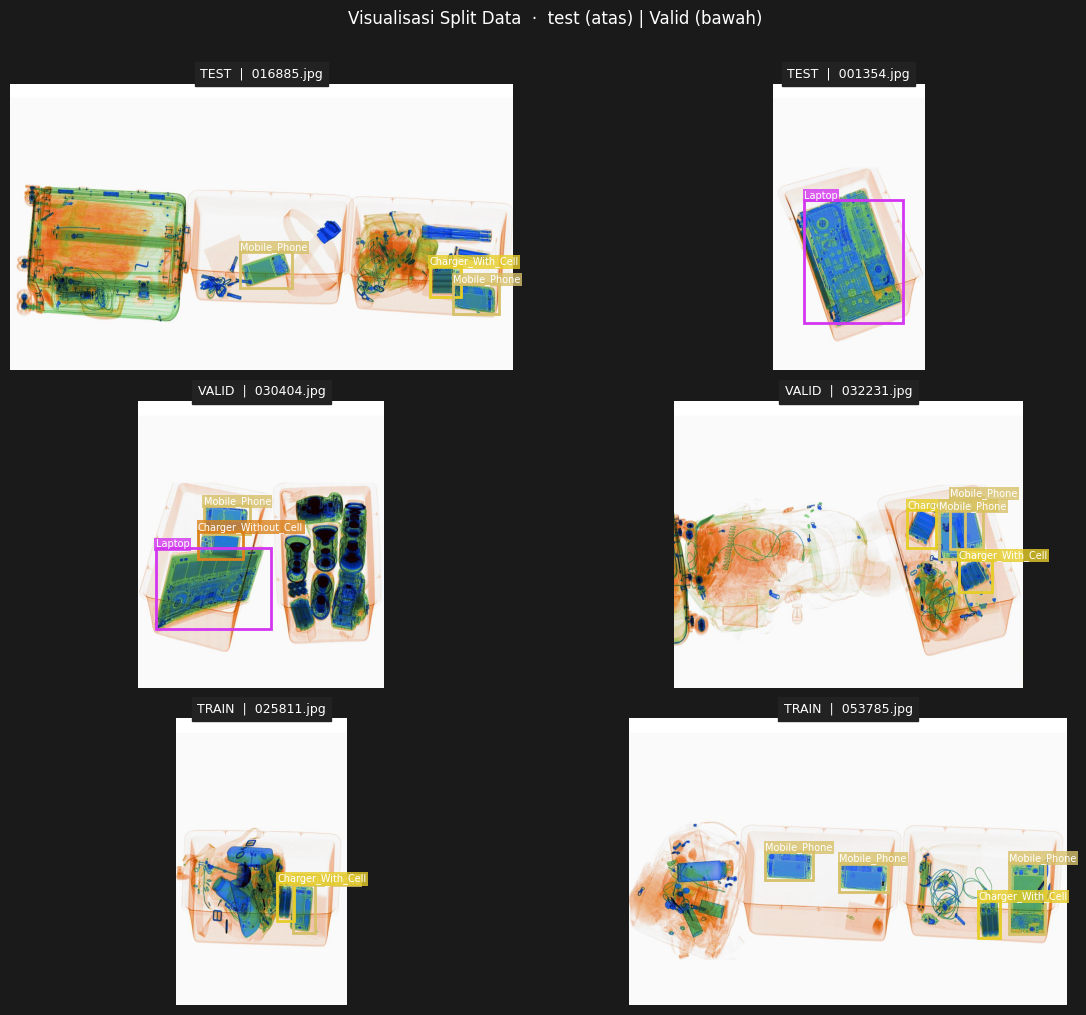

In [38]:
# Fungsi untuk sampling beberapa gambar secara acak dari folder
def sample_images(img_dir, n=2):
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]
    return random.sample(files, min(n, len(files)))

test_samples  = sample_images(processed_images_test,  n=2)
val_samples   = sample_images(processed_images_val,   n=2)
train_sampels = sample_images(processed_images_train, n=2)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Visualisasi Split Data  ·  test (atas) | Valid (bawah)",
    color="white", fontsize=12, y=1.01
)

# ── Baris atas: test ─────────────────────────────────────────────────
for i, fname in enumerate(test_samples):
    stem      = os.path.splitext(fname)[0]
    img_path  = os.path.join(processed_images_test, fname)
    lbl_path  = os.path.join(processed_labels_test, stem + ".txt")
    draw_image_with_boxes(
        axes[0, i], img_path, lbl_path,
        title=f"TEST  |  {fname}"
    )

# ── Baris bawah: Valid ────────────────────────────────────────────────
for i, fname in enumerate(val_samples):
    stem      = os.path.splitext(fname)[0]
    img_path  = os.path.join(processed_images_val, fname)
    lbl_path  = os.path.join(processed_labels_val, stem + ".txt")
    draw_image_with_boxes(
        axes[1, i], img_path, lbl_path,
        title=f"VALID  |  {fname}"
    )

# ── Baris bawah: Valid ────────────────────────────────────────────────
for i, fname in enumerate(train_sampels):
    stem      = os.path.splitext(fname)[0]
    img_path  = os.path.join(processed_images_train, fname)
    lbl_path  = os.path.join(processed_labels_train, stem + ".txt")
    draw_image_with_boxes(
        axes[2, i], img_path, lbl_path,
        title=f"TRAIN  |  {fname}"
    )

for ax in axes.flat:
    ax.set_facecolor("#2a2a2a")

plt.tight_layout()
# plt.savefig("split_preview.png", dpi=150, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
plt.show()
# print("Tersimpan: split_preview.png")